In [19]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error

In [20]:
df = pd.read_csv("housing.csv")

In [21]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


In [22]:
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [23]:
print(df.isnull().sum(), '\n', df.duplicated().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64 
 0


In [24]:
mean = df['total_bedrooms'].mean()
df['total_bedrooms'] = df['total_bedrooms'].fillna(mean)

In [25]:
unique = df['ocean_proximity'].unique()
print(unique)

['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


In [26]:
# one hot encoding cuz there's many
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype= int)

In [27]:
print(df.isnull().sum(), '\n', df.duplicated().sum(), '\n', df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_<1H OCEAN   20640 non-null  int64  
 10  ocean_proximity_INLAND      20640 non-null  int64  
 11  ocean_proximity_ISLAND      20640 non-null  int64  
 12  ocean_proximity_NEAR BAY    20640 non-null  int64  
 13  ocean_proximity_NEAR OCEAN  206

In [28]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

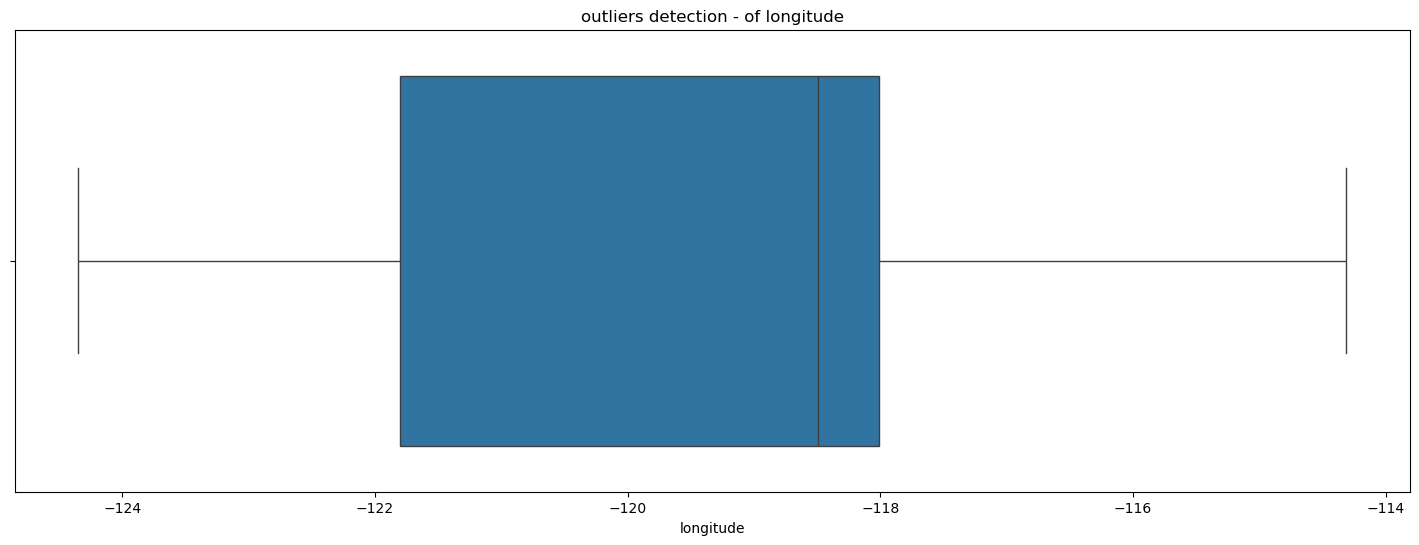

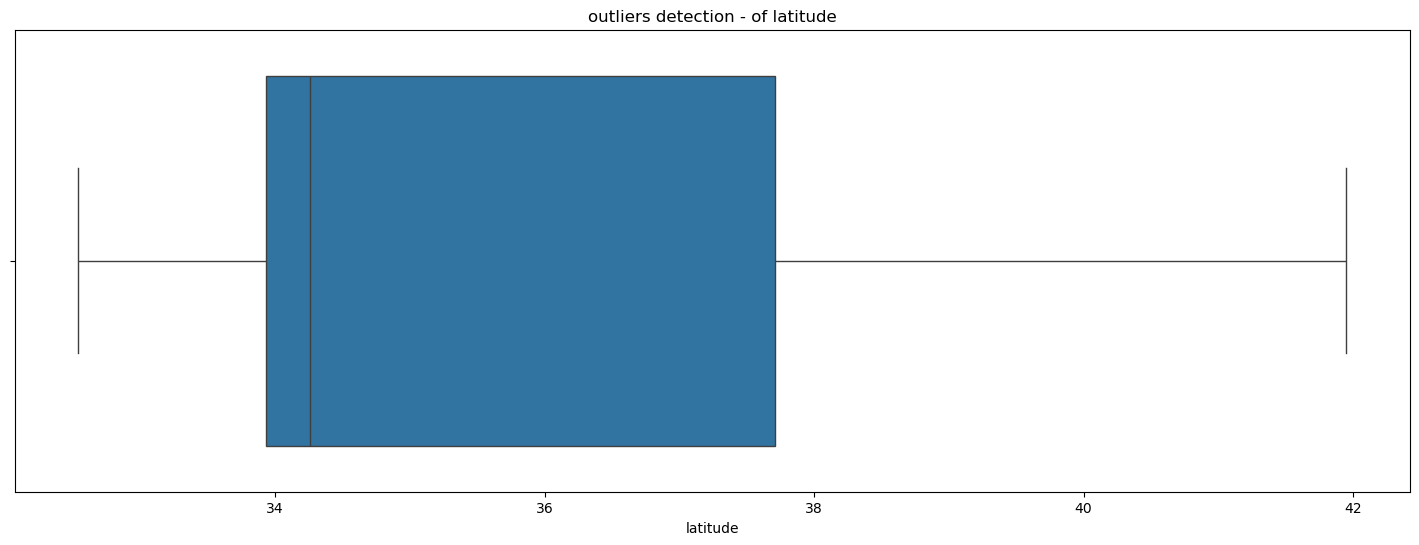

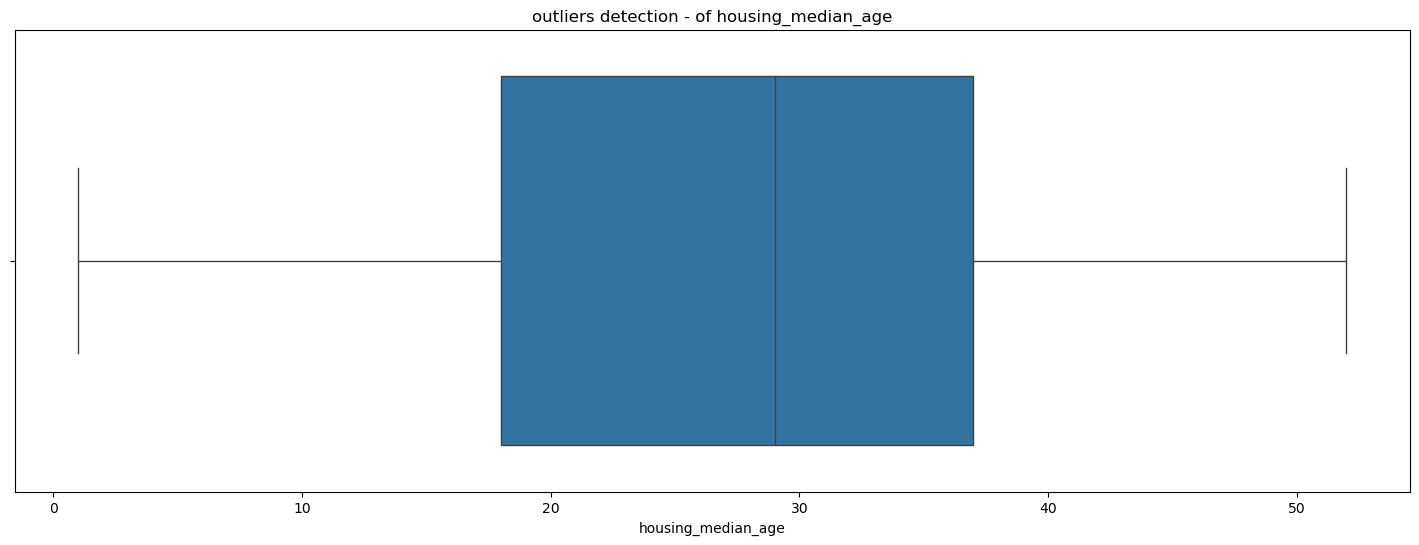

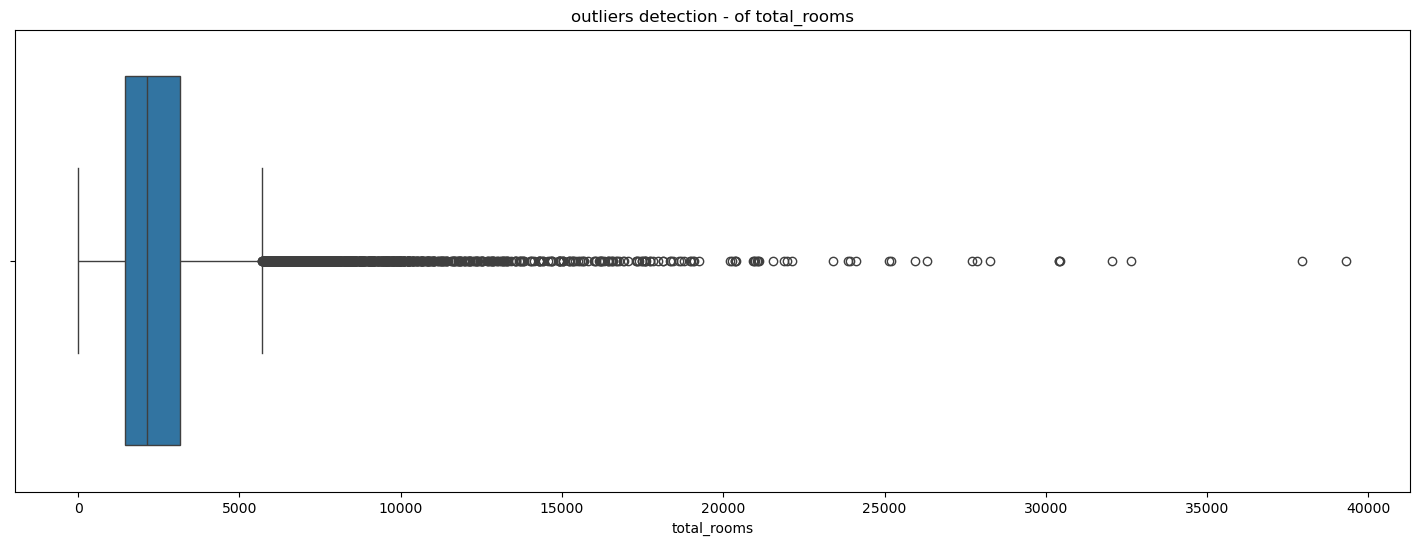

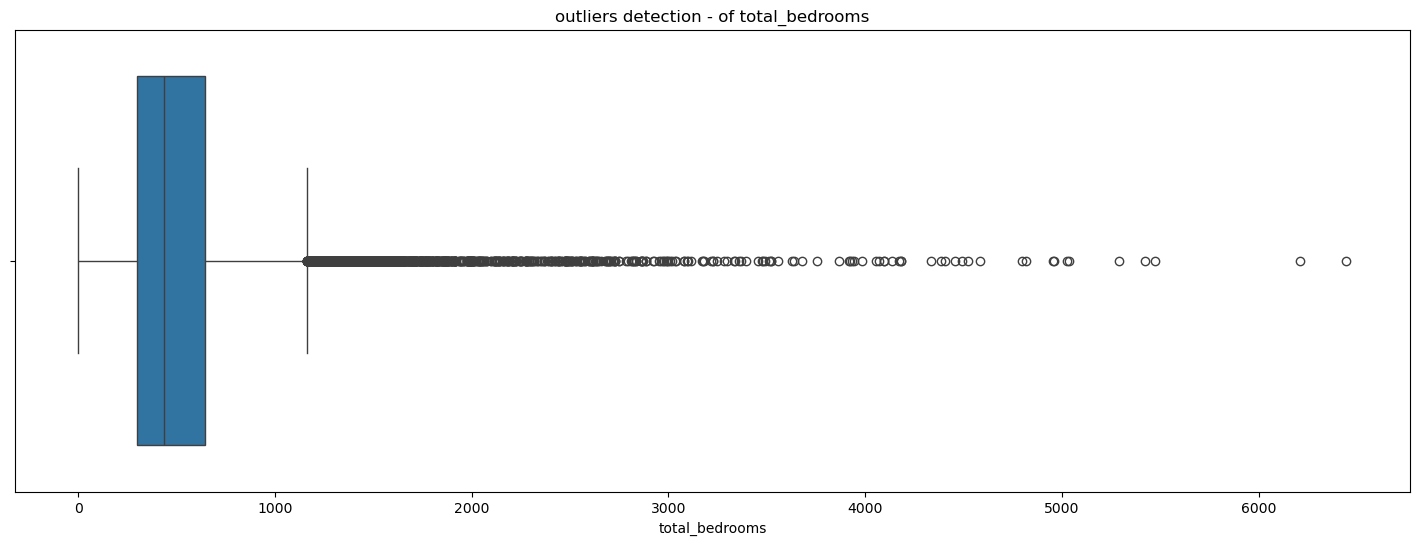

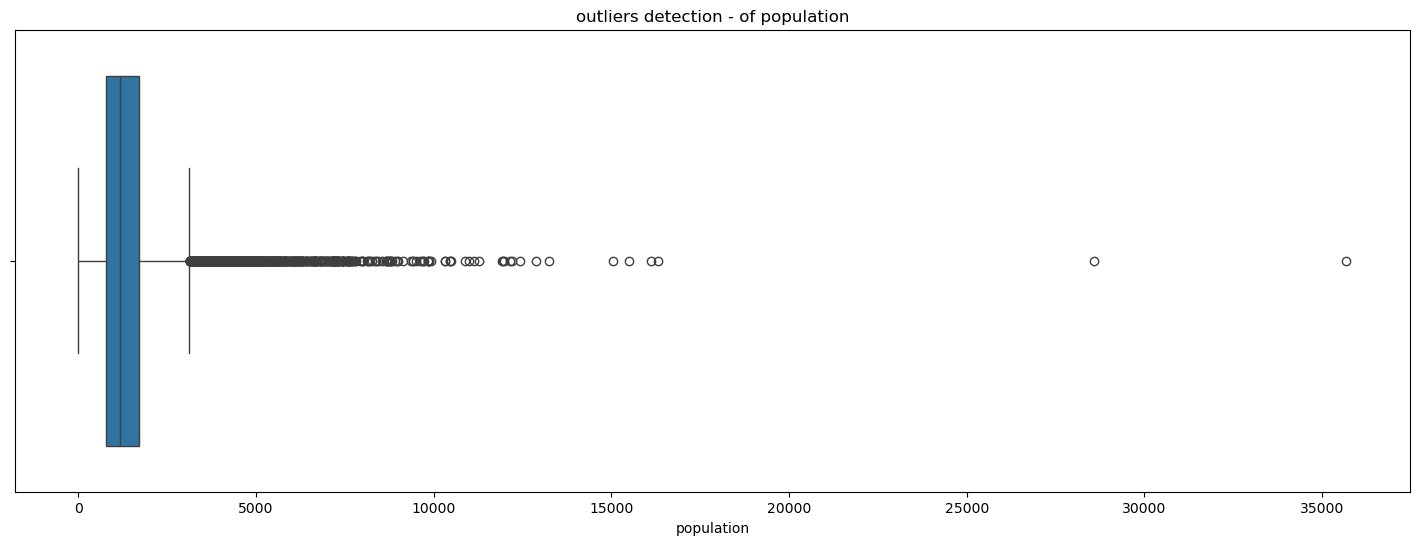

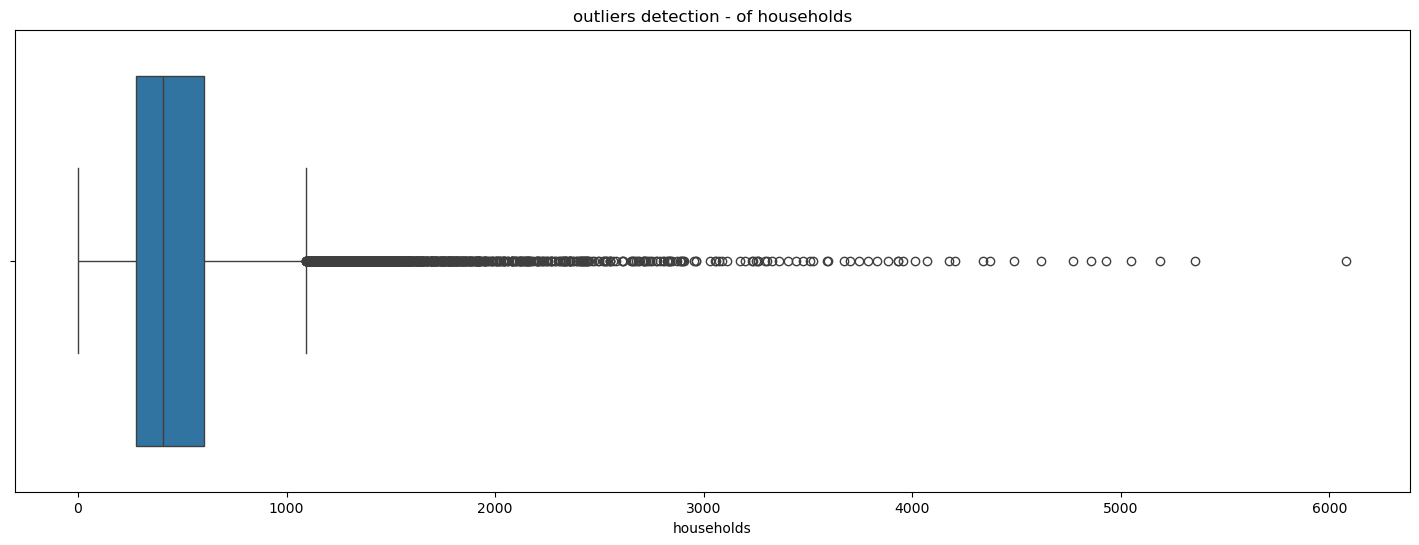

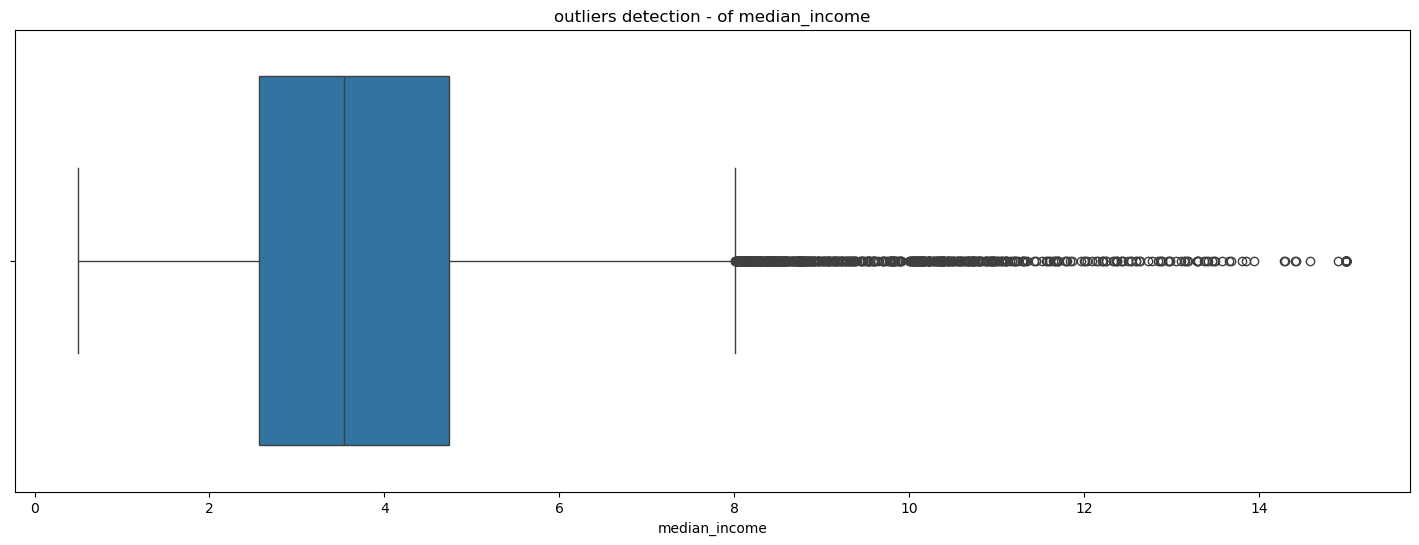

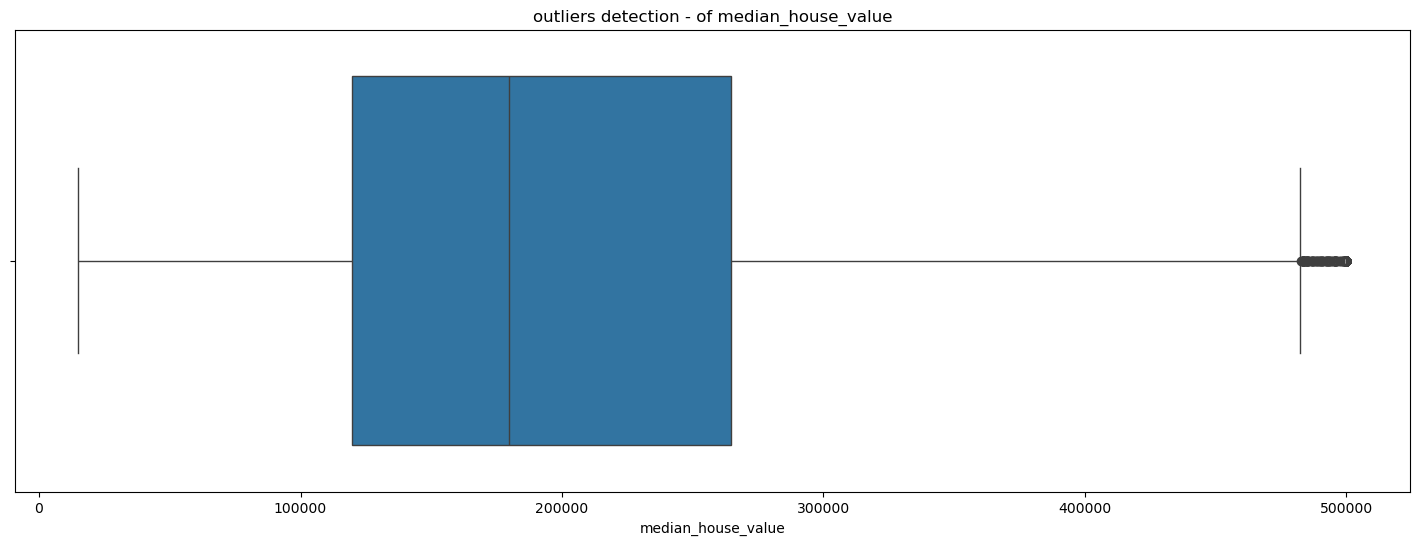

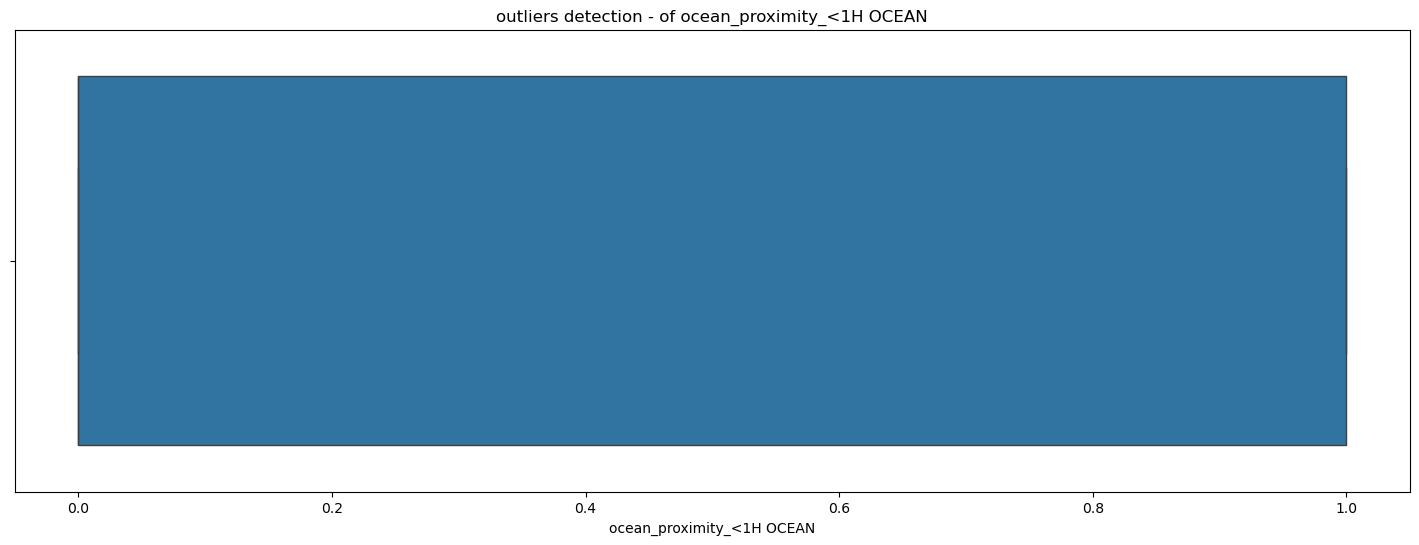

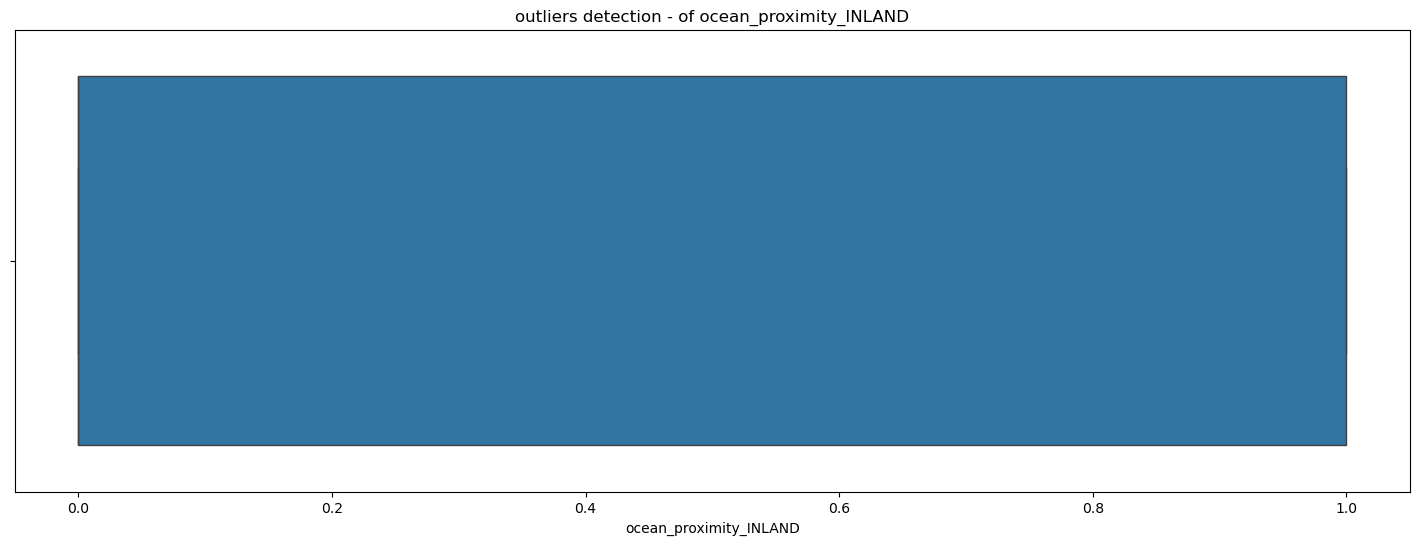

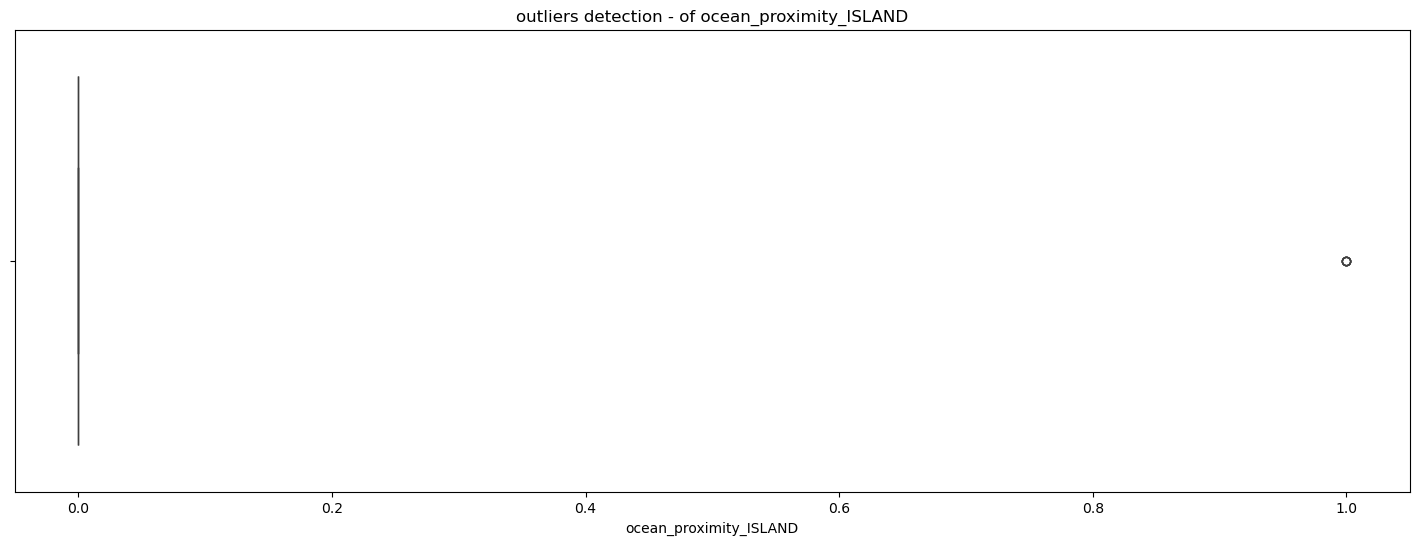

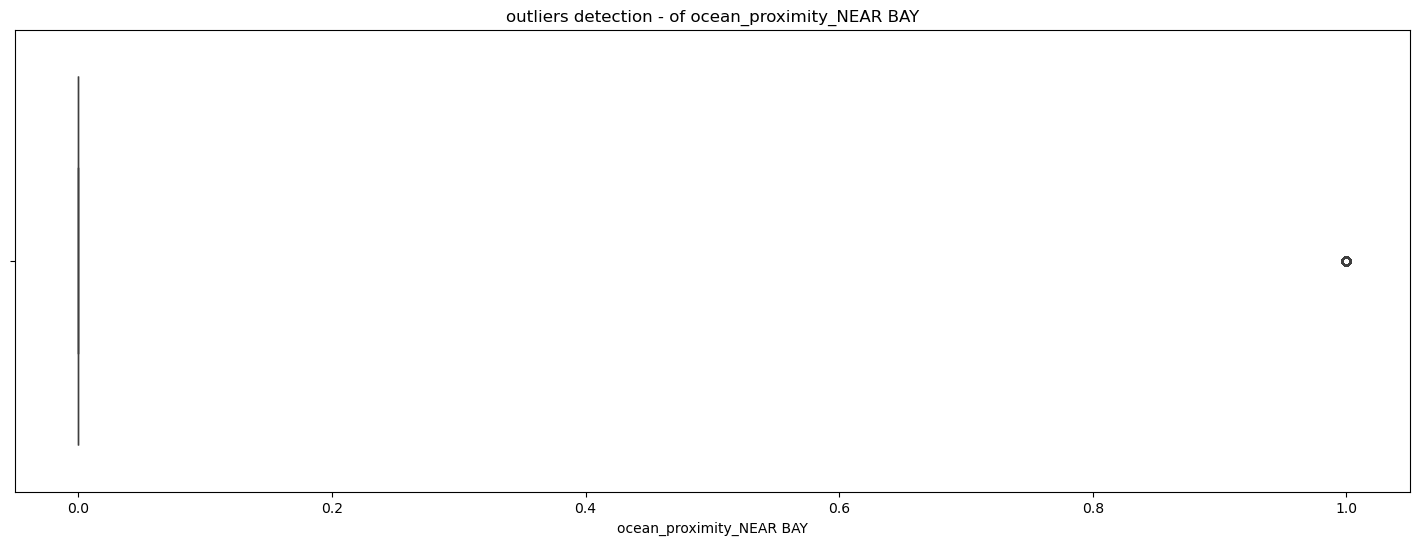

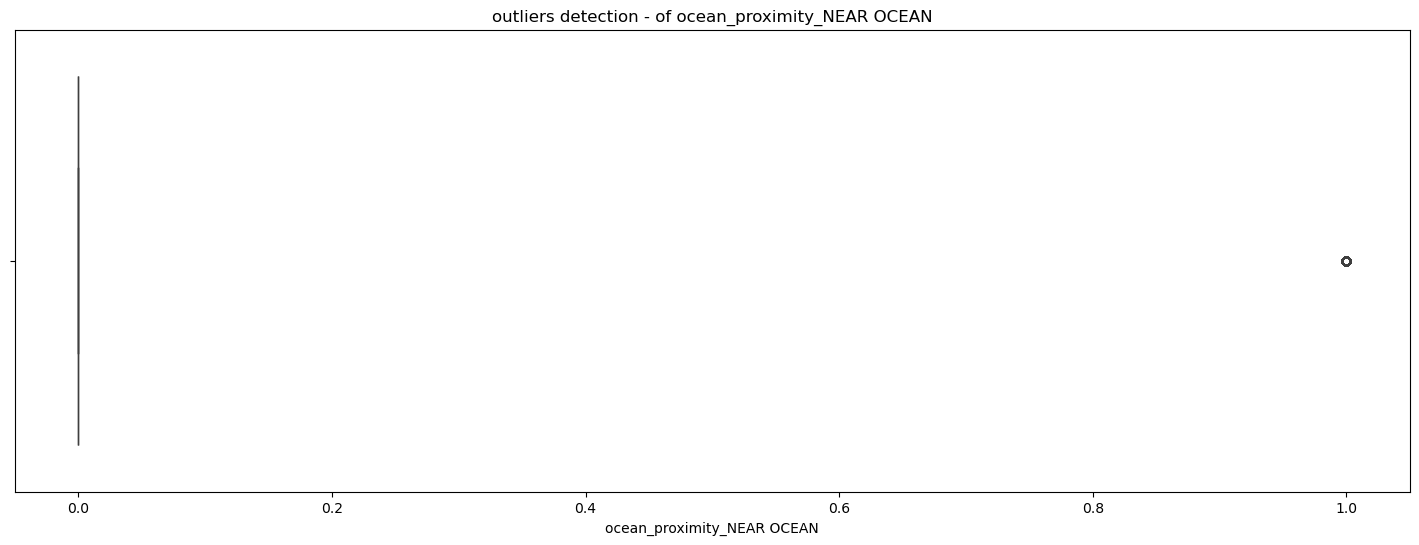

In [29]:
for col in columns:
    plt.figure(figsize=(18,6))
    sns.boxplot(x=df[col])
    plt.title(f'outliers detection - of {col}')
    plt.show()

In [30]:
# noticed which columns have outliers, the ones with too many outliers will use lo transformation while the less ones can be removed if not imp
# import numpy for log transformation

In [31]:
df[['total_rooms','total_bedrooms','population','households','median_income','median_house_value','ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']] = np.log1p(df[['total_rooms','total_bedrooms','population','households','median_income','median_house_value','ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']])

In [32]:
#this was bcz i wanted to see the relationship between two variables hence its called bivariate
# sns.scatterplot(x='households', y='median_house_value', color='red', data=df)
#plt.title('relationship between median house value and other columns')
#plt.show()

In [33]:
x = df[['households','total_bedrooms','median_income','ocean_proximity_<1H OCEAN','ocean_proximity_INLAND','ocean_proximity_ISLAND','ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN','latitude','housing_median_age','total_rooms','population']]
y = df['median_house_value']

In [34]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [35]:
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
predictions = model.predict(x_test)

In [37]:
print(f"mean absolute error: {mean_absolute_error(y_test, predictions)}\n",
      f"Root mean squared error: {root_mean_squared_error(y_test, predictions)}\n",
      f"r2 score: {r2_score(y_test, predictions)}\n",
      f"error rate:{mean_absolute_percentage_error(y_test, predictions)}")

mean absolute error: 0.24979849288313974
 Root mean squared error: 0.33478037737203314
 r2 score: 0.6546788373667871
 error rate:0.020777336215996915
